# Lab 2 · From backpropagation to a PyTorch image classifier

**BME · MSc Deep Learning / VITMMA19 · Fall 2026/2027**  
Department of Telecommunications and Artificial Intelligence  
**Instructor:** Dr. Mohammed Salah Al-Radhi


Follow this notebook with the instructor, then complete **02_BME_DL_Lab2_Assignment.ipynb** independently.
The suggested guided part is **35 minutes**, after **5 minutes of setup**. Optional sections are clearly marked.

By the end, you should be able to explain a gradient update, read image tensor shapes, train a small model, and separate validation from final testing.

**Connection to yesterday:** we turn the computational graph from the backpropagation lecture (slide 30) into PyTorch code. We then examine devices and memory from the hardware lecture. A small CNN is our worked example; detailed CNN architecture design is not a prerequisite.

| Lab 1 idea | PyTorch equivalent today |
| --- | --- |
| Trainable `tf.Variable` | Tensor with `requires_grad=True`; model weights are `nn.Parameter` objects |
| `tf.GradientTape` | PyTorch records a graph during the forward pass |
| Gradient and parameter update | `loss.backward()` fills `.grad`; `optimizer.step()` updates weights |

**Predict → run → explain:** pause at each question before executing the next cell.


## 0. Setup and device choice

Save your own copy in Drive and run cells in order. Use the installed Colab PyTorch/torchvision versions; no package upgrade is needed for the normal Colab workflow.
**CPU is sufficient for the core lab.** If a GPU is available, select it before running setup. Switching runtime can clear variables and downloaded files.
Seeds reduce random variation; identical results across different devices or package versions are not guaranteed.


In [1]:
import os
import random
import time
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
DATA_ROOT = 'data'  # Use the same cache directory for both notebooks.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(min(2, os.cpu_count() or 1))
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print('Python:', platform.python_version())
print('PyTorch:', torch.__version__, '| torchvision:', torchvision.__version__)
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    info = torch.cuda.get_device_properties(DEVICE)
    print('GPU:', info.name, '| total memory:', round(info.total_memory / 2**30, 2), 'GiB')
else:
    print('CPU mode: the core tasks do not require a GPU.')


Python: 3.12.14
PyTorch: 2.8.0+cpu | torchvision: 0.23.0+cpu
Device: cpu
CPU mode: the core tasks do not require a GPU.


## 1. Tensors, devices, and memory

PyTorch keeps tensor data on a particular device. The model, inputs, and target labels used in the loss must be on compatible devices.
For this lab, inputs use `float32` and class-index targets use `int64` (`torch.long`).

**Predict:** how many bytes does a 2×3 float32 tensor contain? Does `.to(DEVICE)` modify the original tensor in place?


In [2]:
x = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
x_on_device = x.to(DEVICE)
print('Shape / dtype / device:', tuple(x.shape), x.dtype, x.device)
print('Selected-device tensor:', x_on_device.device)
print('Tensor storage:', x.numel() * x.element_size(), 'bytes')
print('Matrix product shape:', tuple((x @ x.T).shape))


Shape / dtype / device: (2, 3) torch.float32 cpu
Selected-device tensor: cpu
Tensor storage: 24 bytes
Matrix product shape: (2, 2)


## 2. Yesterday's computational graph in code

Use $L=(wx+b-y)^2$ with $x=2$, $y=3$, $w=0.5$, and $b=1$.
The chain rule gives $\partial L/\partial w=2(wx+b-y)x$ and $\partial L/\partial b=2(wx+b-y)$.

**Predict:** calculate the loss and both gradients. With learning rate 0.1, will the new prediction move towards the target?


In [3]:
x_scalar, target = 2.0, 3.0
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
optimizer_scalar = torch.optim.SGD([w, b], lr=0.1)
optimizer_scalar.zero_grad(set_to_none=True)
prediction = w * x_scalar + b
loss = (prediction - target) ** 2
loss.backward()
print('Before step: prediction =', prediction.item(), '| loss =', loss.item())
print('Autograd: dL/dw =', w.grad.item(), '| dL/db =', b.grad.item())
assert torch.allclose(w.grad, torch.tensor(-4.0))
assert torch.allclose(b.grad, torch.tensor(-2.0))
optimizer_scalar.step()
with torch.no_grad():
    new_prediction = w * x_scalar + b
    new_loss = (new_prediction - target) ** 2
print('After step: w =', round(w.item(), 4), '| b =', round(b.item(), 4))
print('New prediction =', new_prediction.item(), '| new loss =', new_loss.item())


Before step: prediction = 2.0 | loss = 1.0
Autograd: dL/dw = -4.0 | dL/db = -2.0
After step: w = 0.9 | b = 1.2
New prediction = 3.0 | new loss = 0.0


### Why do we clear gradients?

`backward()` accumulates into existing `.grad` buffers. It does **not** update parameters by itself.
We normally want the gradient for the current mini-batch, so we clear old gradients before its backward pass.
Intentional accumulation over several mini-batches is a different training strategy.


In [4]:
probe = torch.tensor(0.0, requires_grad=True)
for pass_number in [1, 2]:
    ((probe - 3) ** 2).backward()  # A fresh graph, but the same gradient buffer.
    print(f'Backward pass {pass_number}: gradient = {probe.grad.item()}')
probe.grad = None
((probe - 3) ** 2).backward()
print('After clearing, one backward pass gives:', probe.grad.item())


Backward pass 1: gradient = -6.0
Backward pass 2: gradient = -12.0
After clearing, one backward pass gives: -6.0


## 3. Data, mini-batches, and training-only normalisation

Fashion-MNIST contains 28×28 grayscale images in ten clothing classes. For class time, we use **4,000 training** and **1,000 validation** images.
The first download needs internet access. The full dataset is downloaded even though training uses a subset.

`Dataset` supplies one transformed sample; `DataLoader` groups samples into mini-batches.
`ToTensor()` maps these uint8 image pixels from 0–255 to 0–1. We then compute per-channel mean/std **only from our selected training images**, and reuse them for validation and testing.
Validation/test data need not have exactly zero mean and unit variance after this transformation.


In [5]:
#@title Provided data helpers — run this cell; expand to inspect
def training_channel_stats(raw_images, train_indices):
    """Mean/std over selected training images and spatial positions, per channel."""
    total = None
    total_sq = None
    count = 0
    # Small chunks avoid making a floating-point copy of the full dataset.
    for start in range(0, len(train_indices), 256):
        idx = train_indices[start:start + 256]
        batch = np.asarray(raw_images[idx], dtype=np.float64) / 255.0
        if batch.ndim == 3:  # Fashion-MNIST: N,H,W -> N,H,W,1
            batch = batch[..., None]
        pixels = batch.reshape(-1, batch.shape[-1])
        if total is None:
            total = np.zeros(pixels.shape[1])
            total_sq = np.zeros(pixels.shape[1])
        total += pixels.sum(axis=0)
        total_sq += (pixels ** 2).sum(axis=0)
        count += pixels.shape[0]
    mean = total / count
    std = np.sqrt(np.maximum(total_sq / count - mean ** 2, 1e-12))
    return tuple(mean.tolist()), tuple(std.tolist())

def make_loader(dataset, shuffle=False, seed=SEED):
    # A separate generator keeps shuffle order independent of plotting/model code.
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE.type == 'cuda'),
                      generator=torch.Generator().manual_seed(seed))

def show_images(images, labels, class_names, mean, std, predictions=None, n=10):
    images = images.detach().cpu()
    n = min(n, len(images))
    if n == 0:
        print('No images to display.')
        return
    columns = min(5, n)
    rows = (n + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(2.6 * columns, 2.7 * rows), squeeze=False)
    m = torch.tensor(mean).view(-1, 1, 1)
    s = torch.tensor(std).view(-1, 1, 1)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i >= n:
            continue
        restored = (images[i] * s + m).clamp(0, 1)
        if restored.shape[0] == 1:
            ax.imshow(restored[0], cmap='gray', vmin=0, vmax=1)
        else:
            ax.imshow(restored.permute(1, 2, 0))
        title = 'True: ' + class_names[int(labels[i])]
        if predictions is not None:
            title += '\nPred: ' + class_names[int(predictions[i])]
        ax.set_title(title, fontsize=10)
    fig.tight_layout()
    plt.show()


In [6]:
BATCH_SIZE = 128
N_TRAIN, N_VAL, N_TEST = 4000, 1000, 1000
EPOCHS = 2

raw_train = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=True)
permutation = torch.randperm(len(raw_train), generator=torch.Generator().manual_seed(SEED)).tolist()
train_idx = permutation[:N_TRAIN]
val_idx = permutation[N_TRAIN:N_TRAIN + N_VAL]
assert set(train_idx).isdisjoint(val_idx)

MEAN, STD = training_channel_stats(raw_train.data, train_idx)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
raw_train.transform = transform
train_dataset = Subset(raw_train, train_idx)
val_dataset = Subset(raw_train, val_idx)
class_names = raw_train.classes
train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset)

print('Training / validation:', len(train_dataset), '/', len(val_dataset))
print('Training-only channel mean:', np.round(MEAN, 4))
print('Training-only channel std :', np.round(STD, 4))
print('Epochs per experiment:', EPOCHS)
print('The test split is held back until final evaluation.')


Training / validation: 4000 / 1000
Training-only channel mean: [0.2879]
Training-only channel std : [0.3542]
Epochs per experiment: 2
The test split is held back until final evaluation.


Images: (128, 1, 28, 28) torch.float32
Labels: (128,) torch.int64
Normalised range: -0.813 to 2.01


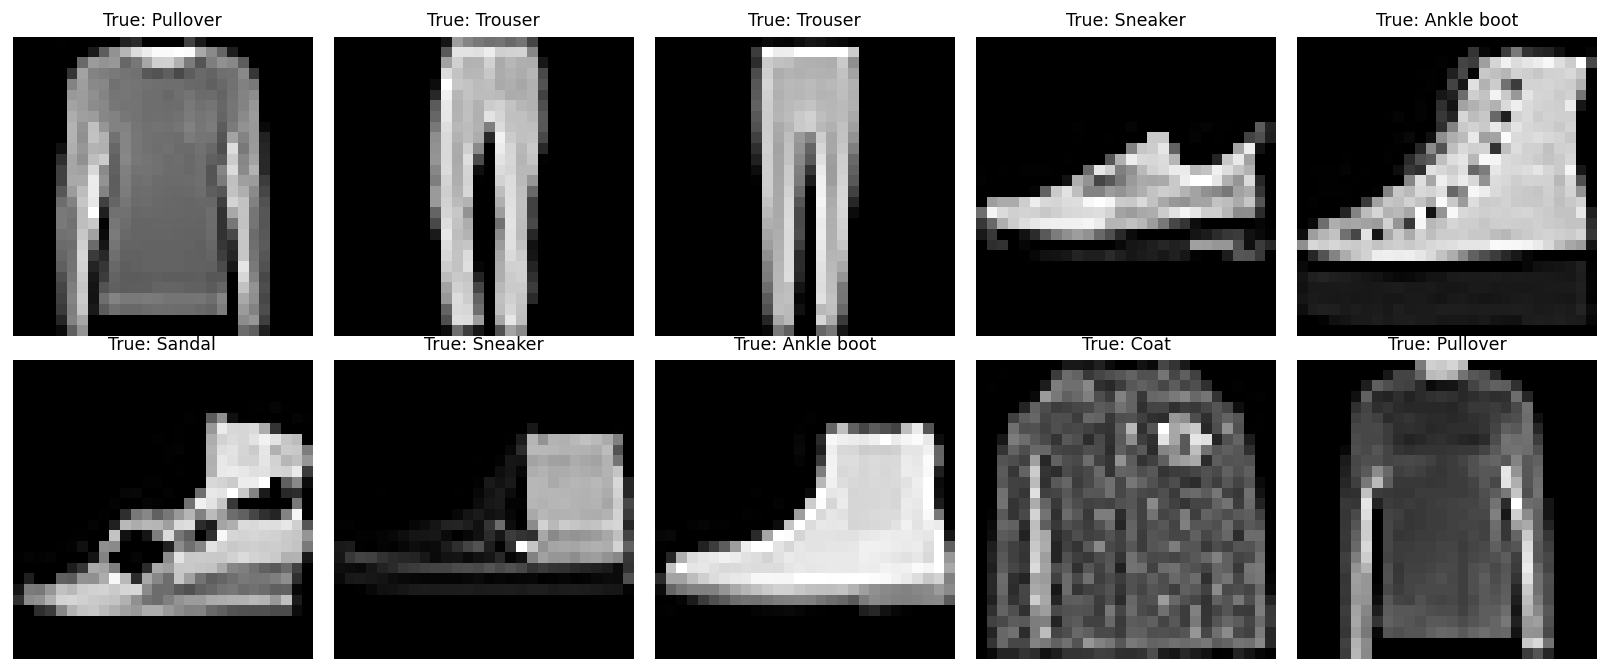

In [7]:
images, labels = next(iter(train_loader))
print('Images:', tuple(images.shape), images.dtype)
print('Labels:', tuple(labels.shape), labels.dtype)
print('Normalised range:', round(images.min().item(), 3), 'to', round(images.max().item(), 3))
show_images(images, labels, class_names, MEAN, STD)


`[128, 1, 28, 28]` means **batch × channels × height × width** (NCHW). The last mini-batch may contain fewer than 128 images.
Normalised pixel values are not restricted to 0–1. For plotting, undo normalisation with `image * std + mean`.

**Check:** why would using validation images to calculate the mean/std contradict yesterday's lecture?


## 4. A small CNN: learn patterns, then produce class scores

A convolution applies the same learned filter at different image positions. It learns useful local patterns; we do not supply hand-drawn edge filters.
ReLU adds non-linearity, and 2×2 max pooling halves these spatial dimensions.

| Stage | Shape, excluding the batch axis |
| --- | --- |
| Input | 1 × 28 × 28 |
| Conv 1 → ReLU → pool | 16 × 14 × 14 |
| Conv 2 → ReLU → pool | 32 × 7 × 7 |
| Flatten | 1,568 |
| Linear → ReLU → dropout → linear | 10 logits |

Our 3×3 convolutions use stride 1 and padding 1, so convolution preserves height/width here. Pooling reduces them.
Dropout randomly zeros some hidden activations during training; it is disabled during evaluation.
**Predict:** what should the output shape be for four images?


In [8]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(128, 10))

    def forward(self, x):
        return self.classifier(self.features(x))

shape_model = FashionCNN().to(DEVICE).eval()
with torch.no_grad():
    output = shape_model(torch.zeros(4, 1, 28, 28, device=DEVICE))
print('Output shape:', tuple(output.shape))
assert output.shape == (4, 10)


Output shape: (4, 10)


In [9]:
parameter_count = sum(p.numel() for p in shape_model.parameters())
weight_bytes = sum(p.numel() * p.element_size() for p in shape_model.parameters())
print('Trainable parameters:', f'{parameter_count:,}')
print('FP32 weight storage:', round(weight_bytes / 2**20, 3), 'MiB')
print('This excludes activations, gradients, optimizer state, and workspace.')


Trainable parameters: 206,922
FP32 weight storage: 0.789 MiB
This excludes activations, gradients, optimizer state, and workspace.


## 5. Loss, backpropagation, and evaluation

`CrossEntropyLoss` takes **raw logits** with shape `[N, 10]` and integer class indices `[N]`, from 0 to 9. It combines log-softmax with the negative log-likelihood calculation; do not put a softmax layer before it.
Adam is our fixed optimizer for this example. The important sequence remains the lecture's **forward → loss → backward → update**. Adam's update uses gradient statistics rather than plain SGD's single fixed-scale subtraction.

Training loop: move batch → clear gradients → forward → loss → backward → optimizer step.
Evaluation: **both** `model.eval()` and `torch.no_grad()` are needed for their different purposes: layer behaviour and gradient recording.


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples


The loss is a batch mean. We multiply it by batch size before accumulating, then divide by the number of samples. This avoids over-weighting a small final batch.

The provided driver below saves an independent copy of the weights at the best validation epoch and restores them at the end. A best validation score must correspond to the weights we subsequently evaluate.


In [11]:
#@title Provided experiment driver — records curves and restores the best checkpoint
def run_experiment(model_factory, learning_rate, epochs, train_data, val_data, run_name):
    # Each call starts from the same seed, fresh weights, fresh optimizer, and shuffle sequence.
    set_seed(SEED)
    model = model_factory().to(DEVICE)
    initial_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    train_loader_run = make_loader(train_data, shuffle=True)
    val_loader_run = make_loader(val_data)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'seconds': []}
    best_acc, best_epoch, best_state = -1.0, None, None
    for epoch in range(1, epochs + 1):
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        train_loss, train_acc = train_one_epoch(model, train_loader_run, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader_run, criterion, DEVICE)
        if not np.isfinite([train_loss, train_acc, val_loss, val_acc]).all():
            raise ValueError('Non-finite metric: inspect the loss, data, and learning rate.')
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start
        for key, value in [('train_loss', train_loss), ('train_acc', train_acc),
                           ('val_loss', val_loss), ('val_acc', val_acc), ('seconds', elapsed)]:
            history[key].append(value)
        if val_acc > best_acc:  # In a tie, keep the earlier checkpoint.
            best_acc, best_epoch = val_acc, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f'{run_name} | epoch {epoch}/{epochs} | '
              f'train loss {train_loss:.3f}, acc {train_acc:.3f} | '
              f'val loss {val_loss:.3f}, acc {val_acc:.3f} | {elapsed:.1f} s')
    model.load_state_dict(best_state)
    model.eval()
    print(f'{run_name}: restored epoch {best_epoch}, validation accuracy {best_acc:.3f}')
    return {'name': run_name, 'model': model, 'history': history, 'lr': learning_rate,
            'best_val_acc': best_acc, 'best_epoch': best_epoch, 'initial_state': initial_state}

def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, metric, label in [(axes[0], 'loss', 'Cross-entropy loss'), (axes[1], 'acc', 'Accuracy')]:
        ax.plot(epochs, history['train_' + metric], 'o-', label='Training (online)')
        ax.plot(epochs, history['val_' + metric], 'o-', label='Validation')
        ax.set(xlabel='Epoch', ylabel=label, xticks=list(epochs))
        ax.legend()
        ax.grid(alpha=0.25)
    axes[1].set_ylim(0, 1)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

@torch.no_grad()
def collect_predictions(model, loader, max_errors=8):
    model.eval()
    true_labels, predicted_labels, mistakes = [], [], []
    for images, labels in loader:
        predictions = model(images.to(DEVICE)).argmax(dim=1).cpu()
        true_labels.extend(labels.tolist())
        predicted_labels.extend(predictions.tolist())
        for idx in torch.where(predictions != labels)[0].tolist():
            if len(mistakes) < max_errors:
                mistakes.append((images[idx].clone(), int(labels[idx]), int(predictions[idx])))
    return np.asarray(true_labels), np.asarray(predicted_labels), mistakes

def show_errors(mistakes, class_names, mean, std):
    if not mistakes:
        print('No misclassified examples in this evaluation set.')
        return
    images = torch.stack([item[0] for item in mistakes])
    labels = torch.tensor([item[1] for item in mistakes])
    predictions = torch.tensor([item[2] for item in mistakes])
    show_images(images, labels, class_names, mean, std, predictions, n=len(mistakes))


Guided | epoch 1/2 | train loss 1.311, acc 0.536 | val loss 0.729, acc 0.753 | 1.6 s
Guided | epoch 2/2 | train loss 0.724, acc 0.731 | val loss 0.605, acc 0.776 | 1.3 s
Guided: restored epoch 2, validation accuracy 0.776


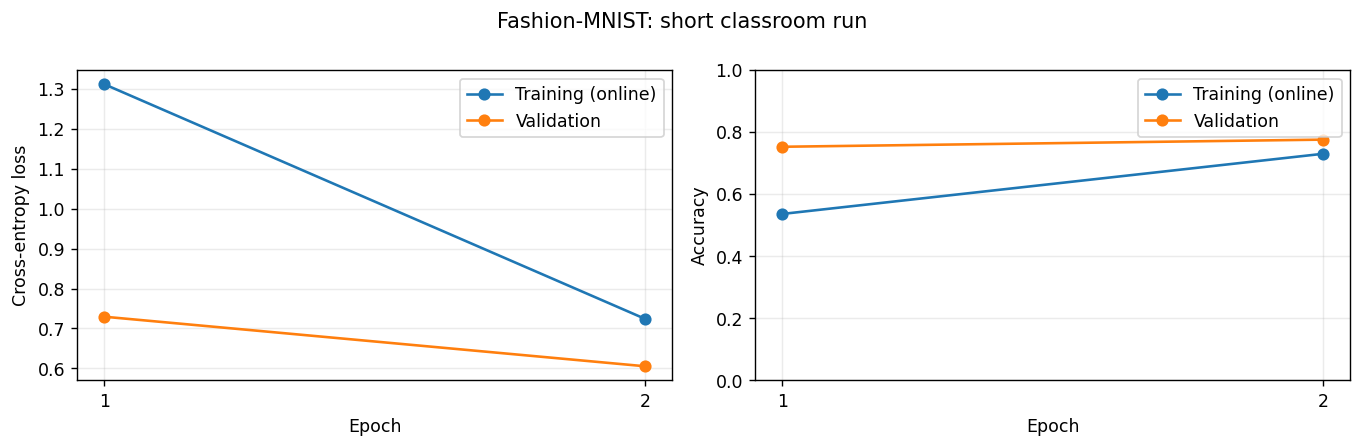

In [12]:
guided_run = run_experiment(FashionCNN, learning_rate=1e-3, epochs=EPOCHS,
                            train_data=train_dataset, val_data=val_dataset, run_name='Guided')
plot_history(guided_run['history'], 'Fashion-MNIST: short classroom run')


## 6. Read the results before making another change

- Did the losses decrease? What evidence supports your answer?
- Which epoch supplied the restored model?
- Why does two epochs on a small subset give limited evidence about generalisation?

Training metrics are collected **while weights are changing**, with dropout active. Validation uses fixed weights with dropout off. Validation accuracy can therefore exceed the reported training accuracy; a gap alone does not prove leakage or overfitting.

**End of the guided core.** Start the five-task assignment now. It uses RGB CIFAR-10 images, but the same training loop. Change just one learning rate for the comparison. Use validation to select the model, then test the selected checkpoint once.


## Optional A. Final testing and error analysis

This fixed test subset has not contributed to normalisation, training, or model selection. It provides a small classroom estimate, not a full benchmark result.
Inspect it only after selecting the checkpoint; do not keep tuning the model based on these errors.


Accuracy on 1000 held-out test images: 0.754


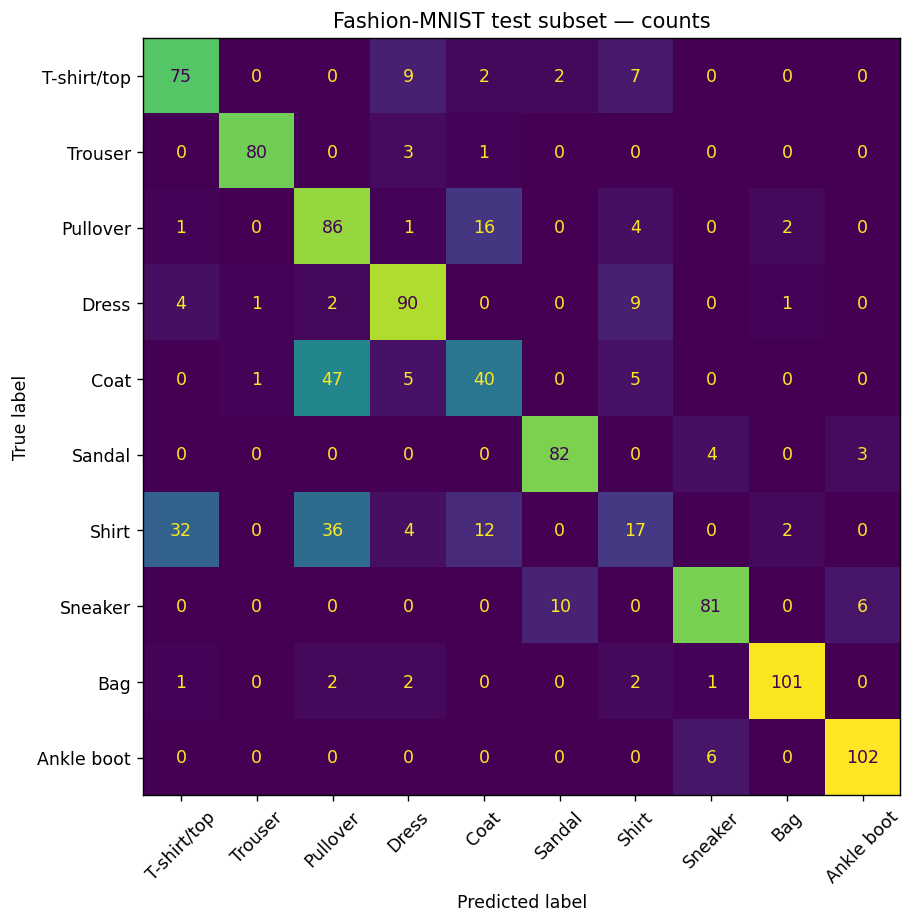

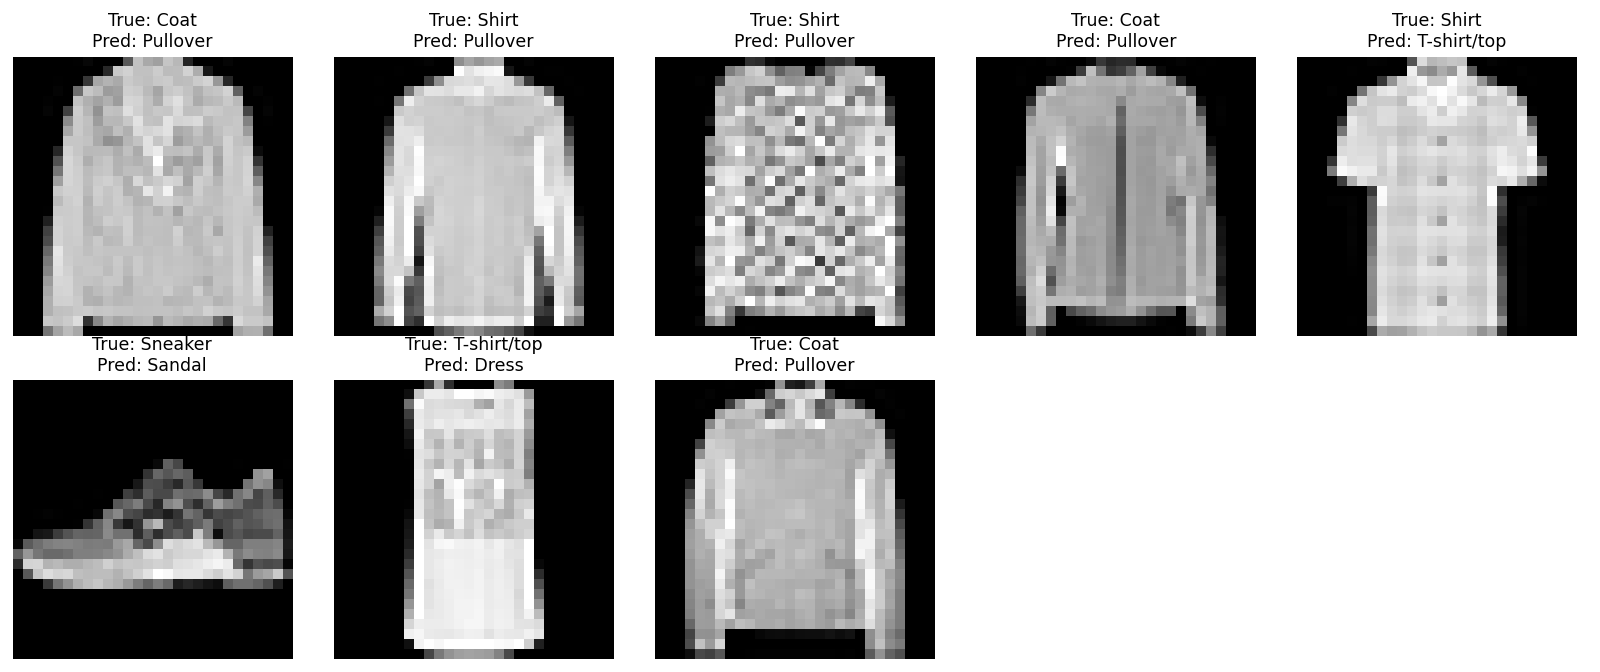

In [13]:
raw_test = datasets.FashionMNIST(root=DATA_ROOT, train=False, download=True, transform=transform)
test_idx = torch.randperm(len(raw_test), generator=torch.Generator().manual_seed(SEED + 1))[:N_TEST].tolist()
test_loader = make_loader(Subset(raw_test, test_idx))
y_true, y_pred, mistakes = collect_predictions(guided_run['model'], test_loader)
print(f'Accuracy on {len(y_true)} held-out test images: {(y_true == y_pred).mean():.3f}')
cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))
fig, ax = plt.subplots(figsize=(8.5, 7.5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Fashion-MNIST test subset — counts')
fig.tight_layout()
plt.show()
show_errors(mistakes, class_names, MEAN, STD)


## Optional B. Why a GPU is not always faster

The hardware lecture emphasised both arithmetic and data movement. This small experiment times **matrix multiplication only**: allocation and CPU–GPU transfers are excluded.
We warm up each device and synchronise CUDA because GPU execution is asynchronous. Results depend on the actual machine, size, kernels, and precision settings; they are not a general CPU/GPU ranking.


In [14]:
@torch.no_grad()
def matmul_milliseconds(size, device, repeats=10):
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)
    for _ in range(3):
        a @ b
    if device.type == 'cuda':
        torch.cuda.synchronize(device)
    start = time.perf_counter()
    for _ in range(repeats):
        a @ b
    if device.type == 'cuda':
        torch.cuda.synchronize(device)
    return 1000 * (time.perf_counter() - start) / repeats

torch.set_float32_matmul_precision('highest')
for size in [128, 1024]:
    cpu_ms = matmul_milliseconds(size, torch.device('cpu'))
    print(f'{size} x {size}: CPU {cpu_ms:.3f} ms', end='')
    if torch.cuda.is_available():
        gpu_ms = matmul_milliseconds(size, torch.device('cuda'))
        print(f' | GPU {gpu_ms:.3f} ms | ratio CPU/GPU {cpu_ms / gpu_ms:.2f}')
    else:
        print(' | GPU comparison skipped: no CUDA device')


128 x 128: CPU 0.039 ms | GPU comparison skipped: no CUDA device
1024 x 1024: CPU 11.352 ms | GPU comparison skipped: no CUDA device


## References and credits

- [PyTorch: tensors and autograd](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html)
- [PyTorch: optimisation loop](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)
- [PyTorch: saving the best model](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)
- [PyTorch: reproducibility](https://docs.pytorch.org/docs/stable/notes/randomness.html)
- [Fashion-MNIST: Xiao, Rasul and Vollgraf / Zalando Research](https://github.com/zalandoresearch/fashion-mnist)
- [CIFAR-10: Alex Krizhevsky / University of Toronto](https://www.cs.toronto.edu/~kriz/cifar.html)

Course material: Dr. Mohammed Salah Al-Radhi, BME. Dataset and framework credits remain with their respective authors. Follow the original terms when reusing third-party material.
